In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler


In [2]:
df = pd.read_csv("Housing.csv")

In [3]:
df1 = df.copy()

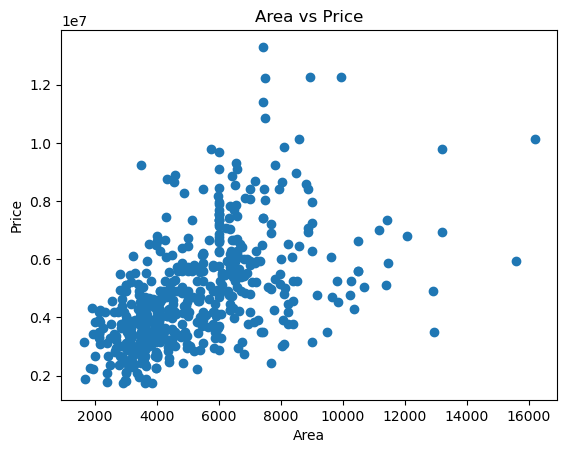

In [4]:
plt.scatter(df1['area'], df['price'])

plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs Price")

plt.show()

In [5]:
df1

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [6]:
cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

for col in cols:
    df1[col] = df1[col].map({"yes": 1, "no": 0})

In [7]:
df1

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,unfurnished
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,semi-furnished
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,unfurnished
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,furnished


In [8]:
#one hot encoding ------
X = df1
df1= pd.get_dummies(X, columns=["furnishingstatus"], drop_first=False, dtype=int)

In [9]:
df1

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,0,0,1
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,0,1,0
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,0,0,1
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,1,0,0


In [10]:
#Train-Test split 
X = df1.drop("price", axis=1)
Y = df1["price"]
X_train , X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2, random_state = 42 )

In [11]:
#Train the linear Regression model  #Model 1
model = LinearRegression()
model.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
#Test the model from test data 
y_pred = model.predict(X_test)

In [13]:
#Evaluating Model Performance 
from sklearn.metrics import r2_score
R2 = r2_score(Y_test, y_pred)

In [14]:
print("R2 SCORE IS : ",R2)

R2 SCORE IS :  0.6529242642153186


In [15]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(Y_test, y_pred)

print("MAE:", mae)

MAE: 970043.4039201637


In [16]:
#Random Forest ALgo  #model 2
from sklearn.ensemble import RandomForestRegressor

model2 = RandomForestRegressor(n_estimators=200, random_state=42)
model2.fit(X_train, Y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
y_pred2 = model2.predict(X_test)

In [108]:
from sklearn.metrics import r2_score
R2_2 = r2_score(Y_test, y_pred2)
print("R2 SCORE FOR RANDOM FOREST :",R2_2)

R2 SCORE FOR RANDOM FOREST : 0.6169508113173195


In [19]:
print(df1.corr(numeric_only=True)['price'].sort_values())

furnishingstatus_unfurnished      -0.280587
furnishingstatus_semi-furnished    0.063656
hotwaterheating                    0.093073
basement                           0.187057
furnishingstatus_furnished         0.229350
guestroom                          0.255517
mainroad                           0.296898
prefarea                           0.329777
bedrooms                           0.366494
parking                            0.384394
stories                            0.420712
airconditioning                    0.452954
bathrooms                          0.517545
area                               0.535997
price                              1.000000
Name: price, dtype: float64


In [91]:
#L2 REgulerzation  #Model 3
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train, Y_train)

y_pred_ridge = ridge.predict(X_test)

In [92]:
#L1  #Model 4
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)

lasso.fit(X_train, Y_train)

y_pred_lasso = lasso.predict(X_test)

In [93]:
from sklearn.metrics import r2_score, mean_absolute_error

print("Ridge R2:", r2_score(Y_test, y_pred_ridge))
print("Ridge MAE:", mean_absolute_error(Y_test, y_pred_ridge))

print("Lasso R2:", r2_score(Y_test, y_pred_lasso))
print("Lasso MAE:", mean_absolute_error(Y_test, y_pred_lasso))

Ridge R2: 0.6524271598634784
Ridge MAE: 970589.5047431185
Lasso R2: 0.6529241865566784
Lasso MAE: 970043.5437239923


In [25]:
########################################################################

In [45]:
df2 = df.copy()

In [46]:
df2

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [47]:
#detecting outliers 

In [48]:
df2.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


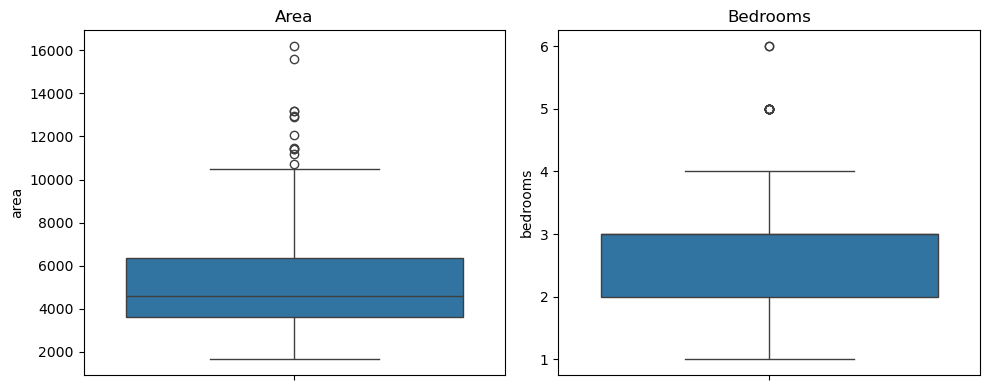

In [49]:


plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['area'])
plt.title('Area')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['bedrooms'])
plt.title('Bedrooms')

plt.tight_layout()
plt.show()

In [50]:
#Outliers 
Q1 = df2["area"].quantile(0.25)
Q3 = df2["area"].quantile(0.73)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
area_outliers = df2[(df2['area'] < lower_bound) | (df2['area'] > upper_bound)]

print(area_outliers)

        price   area  bedrooms  bathrooms  stories mainroad guestroom  \
7    10150000  16200         5          3        2      yes        no   
10    9800000  13200         3          1        2      yes        no   
56    7343000  11440         4          1        2      yes        no   
64    7000000  11175         3          1        1      yes        no   
66    6930000  13200         2          1        1      yes        no   
69    6790000  12090         4          2        2      yes        no   
82    6615000  10500         3          2        1      yes        no   
125   5943000  15600         3          1        1      yes        no   
129   5873000  11460         3          1        3      yes        no   
142   5600000  10500         4          2        2      yes        no   
146   5600000  10500         2          1        1      yes        no   
171   5250000  10269         3          1        1      yes        no   
186   5110000  11410         2          1        2 

In [51]:
Q1 = df2['price'].quantile(0.25)
Q3 = df2['price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

price_outliers = df[
    (df['price'] < lower) |
    (df['price'] > upper)
]

price_outliers

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [52]:
#Remark ---- Seems Genuine price with respecttive combination 
#Remark ---- No Outliers and data is celeaned

In [ ]:
#data_emcoding for dataframe2

In [54]:
cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

for col in cols:
    df2[col] = df2[col].map({"yes": 1, "no": 0})

In [55]:
df2

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,unfurnished
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,semi-furnished
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,unfurnished
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,furnished


In [130]:

df2= pd.get_dummies(df2, columns=["furnishingstatus"], drop_first=False, dtype=int)

KeyError: "None of [Index(['furnishingstatus'], dtype='object')] are in the [columns]"

In [111]:
df2

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,0,0,1
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,0,1,0
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,0,0,1
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,1,0,0


In [112]:
##Feature Scaling and Model 5
X6 = df2.drop("price", axis = 1)
Y6 = df2["price"]

In [113]:
X5_train, X5_test, Y5_train , Y5_test =  train_test_split(X6, Y6, test_size = 0.2 , random_state = 42 )

In [114]:
scaler = StandardScaler()
X5_train = scaler.fit_transform(X5_train)
X5_test = scaler.transform(X5_test)

In [115]:
model5 = LinearRegression()
model5.fit(X5_train, Y5_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [116]:
y5_pred = model5.predict(X5_test)

In [117]:
R2_5 = r2_score(Y6_test, y6_pred)
print("R2 SCORE FOR 5th MODEL IS :", R2_5)

R2 SCORE FOR 5th MODEL IS : 0.6427838635222577


In [118]:
#####Model 6

In [119]:
from sklearn.linear_model import Ridge


ridge = Ridge(alpha=1.0)

ridge.fit(X5_train, Y5_train)

y6_pred_ridge = ridge.predict(X5_test)

r2_ridge = r2_score(Y5_test, y6_pred_ridge)

print("Ridge R²-6th:", r2_ridge)

Ridge R²-6th: 0.6528030426018978


In [120]:
from sklearn.linear_model import Lasso


lasso = Lasso(alpha=1.0)

lasso.fit(X5_train, Y5_train)

y7_pred_lasso = lasso.predict(X5_test)

r2_lasso = r2_score(Y5_test, y7_pred_lasso)

print("Lasso R²-7th:", r2_lasso)

Lasso R²-7th: 0.6529238760179699


In [121]:
#model 8
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X5_train, Y5_train)

rf8_pred = rf.predict(X5_test)

r2_rf = r2_score(Y5_test, rf8_pred)

print("Random Forest R²-8th:", r2_rf)

Random Forest R²-8th: 0.6121287926114543


In [122]:
print("Train R² :", model6.score(X6_train, Y6_train))
print("Test R²  :", model6.score(X6_test, Y6_test))

Train R² : 0.6859438988560158
Test R²  : 0.6427838635222577


In [123]:
###########MODEL 9
# Features and Target
X9 = df2.drop('price', axis=1)

# Log Transform Target
Y9 = np.log(df2['price'])

# Train Test Split
X9_train, X9_test, Y9_train, Y9_test = train_test_split(
    X9,
    Y9,
    test_size=0.2,
    random_state=42
)

# Model 9
model9 = LinearRegression()

model9.fit(X9_train, Y9_train)

# Prediction on Log Scale
y9_pred_log = model9.predict(X9_test)

# R² on Log Scale
R2_9 = r2_score(Y9_test, y9_pred_log)

print("Model 9 R² :", R2_9)

Model 9 R² : 0.6722047299637581


In [124]:
# Convert back to original price scale
y9_pred_price = np.exp(y9_pred_log)

actual_price = np.exp(Y9_test)

comparison = pd.DataFrame({
    'Actual Price': actual_price,
    'Predicted Price': y9_pred_price
})

print(comparison.head())

     Actual Price  Predicted Price
316     4060000.0     4.514297e+06
77      6650000.0     7.152150e+06
360     3710000.0     3.301142e+06
90      6440000.0     4.487025e+06
493     2800000.0     3.352047e+06


In [125]:
print("Train R² :", model9.score(X9_train, Y9_train))
print("Test R²  :", model9.score(X9_test, Y9_test))

Train R² : 0.7039055464508589
Test R²  : 0.6722047299637581


In [127]:
#SOMETHING ELSE 

# -----------------------------
# Feature Engineering
# -----------------------------

df10 = df2.copy()

df10['area_per_bedroom'] = df10['area'] / df10['bedrooms']
df10['total_rooms'] = df10['bedrooms'] + df10['bathrooms']

# -----------------------------
# Features and Target
# -----------------------------

X10 = df10.drop('price', axis=1)

# Log Transformation on Target
Y10 = np.log(df10['price'])

# -----------------------------
# Train Test Split
# -----------------------------

X10_train, X10_test, Y10_train, Y10_test = train_test_split(
    X10,
    Y10,
    test_size=0.2,
    random_state=42
)

# -----------------------------
# Model 10
# -----------------------------

model10 = LinearRegression()

model10.fit(X10_train, Y10_train)

# -----------------------------
# Prediction
# -----------------------------

y10_pred = model10.predict(X10_test)

# -----------------------------
# Evaluation
# -----------------------------

R2_10 = r2_score(Y10_test, y10_pred)

print("Train R² :", model10.score(X10_train, Y10_train))
print("Test R²  :", R2_10)

# -----------------------------
# Convert back to original scale
# -----------------------------

actual_price = np.exp(Y10_test)
predicted_price = np.exp(y10_pred)

comparison = pd.DataFrame({
    'Actual Price': actual_price,
    'Predicted Price': predicted_price
})

print(comparison.head())

Train R² : 0.7042100569696228
Test R²  : 0.6722327962991057
     Actual Price  Predicted Price
316     4060000.0     4.511871e+06
77      6650000.0     7.160603e+06
360     3710000.0     3.303385e+06
90      6440000.0     4.499579e+06
493     2800000.0     3.366563e+06


In [131]:
#model 11
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)

X_poly = poly.fit_transform(X6)

X_train, X_test, y_train, y_test = train_test_split(
    X_poly,
    np.log(df2['price']),
    test_size=0.2,
    random_state=42
)

model11 = LinearRegression()

model11.fit(X_train, y_train)

y_pred = model11.predict(X_test)

print(r2_score(y_test, y_pred))

0.6133403393757841
